In [9]:
import xarray as xr, matplotlib, matplotlib.pyplot as plt, pandas as pd, geopandas as gpd, numpy as np, regionmask, cartopy, os, glob
from shapely.geometry import Polygon
from IPython.display import clear_output

# functions to download from GHCN-D
import sys; sys.path.append('/rds/general/user/cb2714/home/get-station-data'); 
from get_station_data import ghcnd
from get_station_data.util import nearest_stn

# study region
box1_x = [-70, -70, -105, -105, -70]
box1_y = [46, 39, 30, 37, 46]
gdf1 = gpd.GeoDataFrame(index=[0], crs='EPSG:4326', geometry=[Polygon(list(zip(box1_x, box1_y)))])

# path to data on ephemeral
fpath = "/rds/general/user/cb2714/home/00_WWA_project_folder/ephemeral/us-snow/obs/ghcn-d/"

# Station data

## Identify GHCN-D candidate stations

In [ ]:
# import all metadata (only needs to be done once)
stn_md = ghcnd.get_stn_metadata()

In [ ]:
px = gpd.GeoDataFrame(stn_md, geometry = gpd.points_from_xy(stn_md.lon, stn_md.lat), crs = "EPSG:4326").clip(gdf1)
px = px.loc[(px.end_year == 2026) & (px.start_year <= 1950)]

In [30]:
px.to_csv(fpath+"00_station-metadata.csv", index = None)

/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


<GeoAxes: >

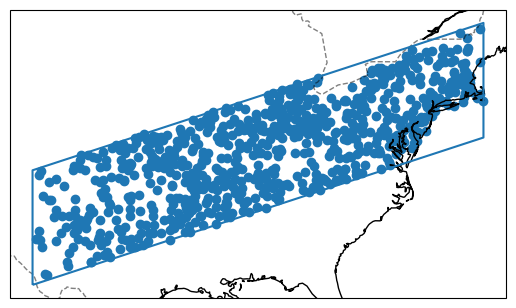

In [69]:
fig, ax = plt.subplots(subplot_kw = {"projection" : cartopy.crs.PlateCarree()})
gdf1.boundary.plot(ax = ax)
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color = "k", alpha = 0.5, ls = "--")
px.plot(ax = ax)

## Loop over stations & download

In [6]:
px = pd.read_csv(fpath+"00_station-metadata.csv")

In [ ]:
for i in range(len(px)):
    print(i, "/", len(px))
    r = px.iloc[[i]]
    new_fnm = fpath+"stn_"+r.station.values[0]+".csv"
    if os.path.exists(new_fnm): continue

    # faster to download without flags, but no QA - should check this in final station selection
    ghcnd.get_data(r, element_types = ["SNOW", "PRCP", "TMAX", "TMIN"], include_flags = False).to_csv(new_fnm, index = None)
    clear_output(wait = False)
print("Done.")

## Update metadata for each variable

In [10]:
md = []
for fnm in glob.glob(fpath+"stn_*.csv"):
    
    stn = fnm.split("_")[-1][:-4]
    df = pd.read_csv(fnm, parse_dates = ["date"])

    # extract data
    min_date = pd.crosstab(index = df.station, columns = df.element, values = df.date, aggfunc = "min")
    max_date = pd.crosstab(index = df.station, columns = df.element, values = df.date, aggfunc = "max")
    counts = pd.crosstab(index = df.station, columns = df.element)
    prop =  counts / ((max_date - min_date ).iloc[0].dt.days + 1)
    years = counts / 365.25

    summ = pd.concat([min_date, max_date, counts, prop, years], axis=1)
    
    summ.columns = [c+"_"+s for c, s in zip(summ.columns, np.repeat(["start", "end", "nobs", "prop", "years"],len(counts.columns)))] # columns have to be non-unique to merge
    md.append(summ)
md = pd.concat(md)
md.to_csv(fpath+"00_station-availability.csv")

## Compile metadata

In [11]:
# compile
px = pd.read_csv(fpath+"00_station-metadata.csv", index_col = "station")
av = pd.read_csv(fpath+"00_station-availability.csv", index_col = "station")
df = pd.merge(px, av, left_index = True, right_index = True)

df.to_csv(fpath+"00_station-metadata-with-availability.csv")

## Filter metadata

In [12]:
px = pd.read_csv(fpath+"00_station-metadata-with-availability.csv", index_col = "station")
px = gpd.GeoDataFrame(px, geometry = gpd.points_from_xy(px.lon, px.lat), crs = "EPSG:4326")

In [13]:
px_snow = px.loc[(px.SNOW_prop ==1) & (px.SNOW_years > 50)]

/rds/general/user/cb2714/home/miniforge3/envs/wwa/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


<GeoAxes: >

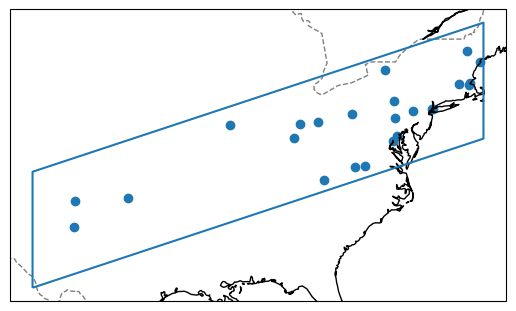

In [14]:
fig, ax = plt.subplots(subplot_kw = {"projection" : cartopy.crs.PlateCarree()})
gdf1.boundary.plot(ax = ax)
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS, color = "k", alpha = 0.5, ls = "--")
px_snow.plot(ax = ax)

In [15]:
px_snow

,lat,lon,elev,name,start_year,end_year,geometry,nyears,PRCP_start,SNOW_start,...,TMAX_start,TMIN_start,TMAX_end,TMIN_end,TMAX_nobs,TMIN_nobs,TMAX_prop,TMIN_prop,TMAX_years,TMIN_years
station,,,,,,,,,,,,,,,,,,,,,
USW00013877,36.4797,-82.3989,456.0,TN BRISTOL AP,1937.0,2026.0,POINT (-82.3989 36.4797),90.0,1937-10-01,1937-10-01,...,1937-10-01,1937-10-01,2026-02-28,2026-02-28,32293.0,32293.0,1.000000,1.000000,88.413415,88.413415
USW00013741,37.3172,-79.9736,346.9,VA ROANOKE-BLACKSBURG RGNL AP,1948.0,2026.0,POINT (-79.9736 37.3172),79.0,1948-01-01,1948-01-01,...,1948-01-01,1948-01-01,2026-02-28,2026-02-28,28549.0,28549.0,1.000000,1.000000,78.162902,78.162902
USW00013733,37.3214,-79.2064,274.9,VA LYNCHBURG RGNL AP,1944.0,2026.0,POINT (-79.2064 37.3214),83.0,1944-08-01,1944-08-01,...,1944-08-01,1944-08-01,2026-02-28,2026-02-28,29797.0,29797.0,1.000000,1.000000,81.579740,81.579740
USW00093814,39.0444,-84.6725,262.4,KY CINCINNATI/NORTHERN KENTUCKY,1948.0,2026.0,POINT (-84.6725 39.0444),79.0,1948-01-01,1948-01-01,...,1948-01-01,1948-01-01,2026-02-28,2026-02-28,28549.0,28549.0,1.000000,1.000000,78.162902,78.162902
USW00014821,39.9906,-82.8769,246.9,OH JOHN GLENN INTL AP,1948.0,2026.0,POINT (-82.8769 39.9906),79.0,1948-01-01,1948-01-01,...,1948-01-01,1948-01-01,2026-02-28,2026-02-28,28549.0,28549.0,1.000000,1.000000,78.162902,78.162902
USW00093815,39.9064,-84.2186,302.7,OH DAYTON INTL AP,1948.0,2026.0,POINT (-84.2186 39.9064),79.0,1948-01-01,1948-01-01,...,1948-01-01,1948-01-01,2026-02-28,2026-02-28,28549.0,28549.0,1.000000,1.000000,78.162902,78.162902
USW00013743,38.8472,-77.0344,4.0,VA WASHINGTON REAGAN NATL AP,1941.0,2026.0,POINT (-77.0344 38.8472),86.0,1941-06-01,1941-06-01,...,1941-06-01,1941-06-01,2026-02-28,2026-02-28,30954.0,30954.0,1.000000,1.000000,84.747433,84.747433
USW00093721,39.1733,-76.6842,42.1,MD BALTIMORE-WASHINGTON INTL AP,1939.0,2026.0,POINT (-76.6842 39.1733),88.0,1939-07-01,1939-07-01,...,1939-07-01,1939-07-01,2026-02-28,2026-02-28,31655.0,31655.0,1.000000,1.000000,86.666667,86.666667
USW00014751,40.2183,-76.8553,102.1,PA HARRISBURG CAPITAL CITY AP,1939.0,2026.0,POINT (-76.8553 40.2183),88.0,1939-01-01,1939-01-01,...,1939-01-01,1939-01-01,2026-02-28,2026-02-28,28548.0,28548.0,0.896721,0.896721,78.160164,78.160164
